# Case Study 4
## Data
https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data
- Impute the dataset
- Look at the data.  Discuss what you see.
- Why or why not do we scale the data.

## Random Forest
- Build and tune a cross validated Random Forest set of models to get our of fold predictions
- When tuning, choose at least 4 hyperparameters to tune with AT LEAST 3 or more values EACH Hyperparameter
- List the results(scores) of your tuning.  You are free to use any classification metric.  Justify your choice
- Compare your results (RF) to the paper results for ROC by year (Statistical Comparison)
- Produce a classification report, confusion matrix and ROC curve for Random Forest
- Discuss your results from the previous step.
- Compare a grid search versus random search (<20 inteations) for final score and time taken.  You can use only 1 year of data to help speed this up

## XGBoost
- Build and tune a cross validatied XBoost model using the XGB package (not the sklearn wrapper).
- When tuning, choose at least 6 hyperparameters to tune with AT LEAST 3 or more values EACH Hyperparameter
- You must implement early stopping
- List the results(scores) of your tuning.  You are free to use any classification metric.  Justify your choice
- Compare your results to the paper results(XGB) for ROC by year (Statistical Comparison)
- Produce a classification report, confusion matrix and ROC curve for the best XGBoost
- Discuss your results from the previous step.

## FORBIDDEN
- You may NOT choose the number of trees as a hyperparameter. It is known that more trees is better for Random Forest, XGBoost relies on Early Stopping
- You may NOT choose the early stopping rounds as a hyperparameter. (Its not a hyperparameter)
- You may NOT choose different loss functions as a hyperparameter. (They are not hyperparameters)
- Train/test splits are forbidden.  All models must be cross validated. (My class, my rules)
- Yes Gini/Entropy can be considered hyperparameters.  Tune something else (My class, my rules).

## Required
- Professional quality graphs.  Labels and Titles are required. If you are making a chart for yourself fine, but those confusion matricies and ROC curves need to be done RIGHT
- Variable names and code comments.  I need to know what you are doing.  You can use i or tmp if it is obvious.  lets's avoid dataframes named "df"
- 

In [46]:
import pandas as pd
data = pd.read_csv("./data/1year.arff") # angry error

ParserError: Error tokenizing data. C error: Expected 1 fields in line 67, saw 2


In [53]:
data = pd.read_csv("./data/1year.arff", skiprows=69, header=None)

In [54]:
data.shape

(7027, 65)

In [55]:
data.describe()

,12,18,19,22,29,30,38,41,42,43,48,54,55,57,61,64
count,7027.000000,7027.000000,7.027000e+03,7027.000000,7027.000000,7027.000000,7027.000000,7027.000000,7.027000e+03,7.027000e+03,7027.000000,7.027000e+03,7.027000e+03,7.027000e+03,7.027000e+03,7027.000000
mean,2.093345,0.462392,1.162128e+03,0.423610,23.568949,0.473717,0.269342,0.263638,4.588504e+03,3.426404e+03,-1.367363,8.855693e+03,-1.577367e+02,1.587409e+02,4.763202e+03,0.038566
std,159.699448,30.646874,9.315822e+04,29.742101,1826.847970,30.647711,27.064231,27.071123,3.627309e+05,2.696211e+05,107.717867,7.247527e+04,1.322125e+04,1.322124e+04,3.107835e+05,0.192571
min,-607.420000,-622.060000,0.000000e+00,-634.590000,-149.070000,-622.060000,-701.630000,-701.630000,0.000000e+00,0.000000e+00,-9001.000000,-8.004700e+05,-1.108300e+06,-4.194000e-03,0.000000e+00,0.000000
25%,0.038073,0.014812,1.708300e+01,0.011253,0.094681,0.019233,0.012786,0.011540,6.525600e+01,3.387300e+01,-0.009992,9.712000e+01,2.031450e-02,8.647650e-01,4.322250e+01,0.000000
50%,0.080830,0.049966,3.561200e+01,0.042097,0.207130,0.056637,0.046948,0.047783,9.461200e+01,5.180000e+01,0.022759,1.604800e+03,6.338200e-02,9.388100e-01,6.850900e+01,0.000000
75%,0.144955,0.104500,6.070100e+01,0.088314,0.365635,0.114970,0.103375,0.102165,1.304150e+02,7.550250e+01,0.075464,5.955900e+03,1.376950e-01,9.820150e-01,1.063350e+02,0.000000
max,13315.000000,2156.800000,7.809200e+06,2156.800000,152860.000000,2156.800000,2156.500000,2156.800000,3.039300e+07,2.258400e+07,31.639000,4.398400e+06,1.000000e+00,1.108300e+06,2.501600e+07,1.000000


In [57]:
data[0]

0         0.20055
1         0.20912
2         0.24866
3        0.081483
4         0.18732
          ...    
7022     0.018371
7023    -0.013359
7024     0.006338
7025    -0.041643
7026     0.014946
Name: 0, Length: 7027, dtype: str

In [63]:
data = pd.read_csv("./data/1year.arff", header=None, skiprows=69, na_values="?") #how to read this all in correctly

In [64]:
data.loc[data[0].isna(),0].shape

(3,)

In [65]:
data.shape

(7027, 65)

In [66]:
for col in range(data.shape[1]):
    missing = data.loc[data[col].isna(),col].shape[0] #looping throuch columns
    if missing > 0:
        print(f"Column {col} has {missing} missing rows")

Column 0 has 3 missing rows
Column 1 has 3 missing rows
Column 2 has 3 missing rows
Column 3 has 30 missing rows
Column 4 has 8 missing rows
Column 5 has 3 missing rows
Column 6 has 3 missing rows
Column 7 has 25 missing rows
Column 8 has 1 missing rows
Column 9 has 3 missing rows
Column 10 has 39 missing rows
Column 11 has 30 missing rows
Column 13 has 3 missing rows
Column 14 has 2 missing rows
Column 15 has 25 missing rows
Column 16 has 25 missing rows
Column 17 has 3 missing rows
Column 20 has 1622 missing rows
Column 21 has 3 missing rows
Column 23 has 124 missing rows
Column 24 has 3 missing rows
Column 25 has 25 missing rows
Column 26 has 311 missing rows
Column 27 has 34 missing rows
Column 28 has 3 missing rows
Column 31 has 38 missing rows
Column 32 has 30 missing rows
Column 33 has 25 missing rows
Column 34 has 3 missing rows
Column 35 has 3 missing rows
Column 36 has 2740 missing rows
Column 37 has 3 missing rows
Column 39 has 30 missing rows
Column 40 has 84 missing rows
C

In [67]:
from sklearn.impute import SimpleImputer
impute = SimpleImputer()
data = pd.DataFrame(impute.fit_transform(data),columns=data.columns) #I like dataframes

In [68]:
data.shape

(7027, 65)

In [69]:
data

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,0.200550,0.37951,0.39641,2.04720,32.3510,0.388250,0.249760,1.330500,1.13890,0.504940,...,0.121960,0.397180,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.42770,0.0
1,0.209120,0.49988,0.47225,1.94470,14.7860,0.000000,0.258340,0.996010,1.69960,0.497880,...,0.121300,0.420020,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.98700,0.0
2,0.248660,0.69592,0.26713,1.55480,-1.1523,0.000000,0.309060,0.436950,1.30900,0.304080,...,0.241140,0.817740,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.20780,0.0
3,0.081483,0.30734,0.45879,2.49280,51.9520,0.149880,0.092704,1.866100,1.05710,0.573530,...,0.054015,0.142070,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.54970,0.0
4,0.187320,0.61323,0.22960,1.40630,-7.3128,0.187320,0.187320,0.630700,1.15590,0.386770,...,0.134850,0.484310,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.89800,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7022,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.274140,73.5050,79.2370,31.268,11.6730,5.14890,1.0
7023,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.805920,10.5990,7.1740,94.092,3.8792,1.75720,1.0
7024,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.000000,10.4700,6.0759,51.019,7.1542,62.00100,1.0
7025,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.593100,39.7030,3.1420,261.850,1.3939,0.51005,1.0


In [71]:
X = data.iloc[:,0:64] #column names are intergers!
y = data.iloc[:,-1]

In [72]:
X.shape

(7027, 64)

In [73]:
y.shape

(7027,)

In [74]:
X

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.200550,0.37951,0.39641,2.04720,32.3510,0.388250,0.249760,1.330500,1.13890,0.504940,...,348690.0,0.121960,0.397180,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.42770
1,0.209120,0.49988,0.47225,1.94470,14.7860,0.000000,0.258340,0.996010,1.69960,0.497880,...,2304.6,0.121300,0.420020,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.98700
2,0.248660,0.69592,0.26713,1.55480,-1.1523,0.000000,0.309060,0.436950,1.30900,0.304080,...,6332.7,0.241140,0.817740,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.20780
3,0.081483,0.30734,0.45879,2.49280,51.9520,0.149880,0.092704,1.866100,1.05710,0.573530,...,20545.0,0.054015,0.142070,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.54970
4,0.187320,0.61323,0.22960,1.40630,-7.3128,0.187320,0.187320,0.630700,1.15590,0.386770,...,3186.6,0.134850,0.484310,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.89800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7022,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,-2732.8,0.011909,0.039866,0.98809,0.274140,73.5050,79.2370,31.268,11.6730,5.14890
7023,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-2557.1,-0.011082,-0.040671,1.01110,0.805920,10.5990,7.1740,94.092,3.8792,1.75720
7024,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,4826.9,0.008258,0.012817,0.99174,0.000000,10.4700,6.0759,51.019,7.1542,62.00100
7025,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-1633.0,-0.232720,-0.274290,0.98788,3.593100,39.7030,3.1420,261.850,1.3939,0.51005


In [76]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
rf_model = RandomForestClassifier(n_estimators=20)
parameters = {
    'criterion':['gini','entropy'], 
    'max_depth': [None,5,10,15,20,25], 
    'min_samples_split':  [4,8,16] ,
    'min_samples_leaf': [1,2,3,4],
}
grid_search = GridSearchCV(rf_model, param_grid=parameters,scoring = 'accuracy', cv = 5,n_jobs=4)
grid_search.fit(X,y)

CPU times: user 183 μs, sys: 1 μs, total: 184 μs
Wall time: 173 μs


In [78]:
%%time
rand_search = RandomizedSearchCV(rf_model, param_distributions=parameters,scoring = 'accuracy', cv = 5,n_jobs=4, n_iter=20)
rand_search.fit(X,y)

CPU times: user 1.11 s, sys: 84.7 ms, total: 1.2 s
Wall time: 20.6 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...estimators=20)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [4, 8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [82]:
from sklearn.model_selection import cross_val_predict
preds = cross_val_predict(rf_model, X, y) # class
prob_preds = cross_val_predict(rf_model, X, y, method="predict_proba") #probabilities---needed for ROC

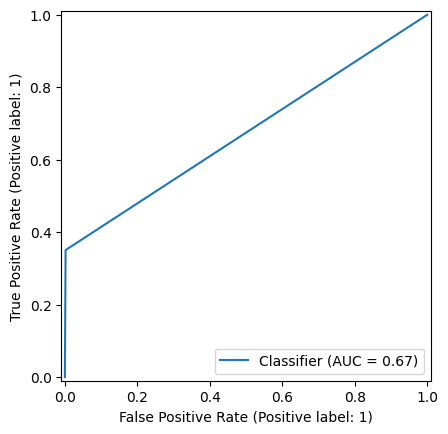

In [80]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y, preds)  #BAD!!!

In [81]:
preds

array([0., 0., 0., ..., 1., 0., 0.], shape=(7027,))

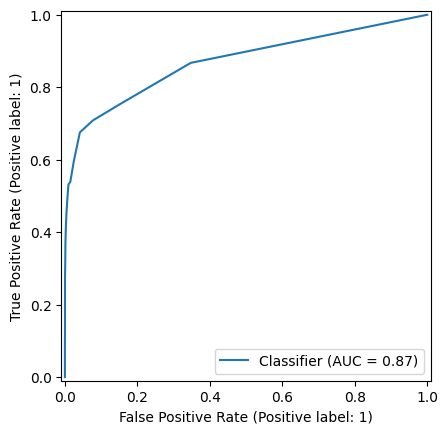

In [86]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y, prob_preds[:,1]) #good

In [85]:
prob_preds[:,1]

array([0.  , 0.  , 0.  , ..., 0.45, 0.1 , 0.2 ], shape=(7027,))